In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from utils.model_classes import LGBModel

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

GRAPH_FEATURES_PATH = PROJECT_ROOT / 'data' / 'graph_features'
TRAIN_PATH = GRAPH_FEATURES_PATH / 'final_train.parquet'
VAL_PATH = GRAPH_FEATURES_PATH / 'final_val.parquet'
TEST_PATH = GRAPH_FEATURES_PATH / 'final_test.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1 if torch.cuda.is_available() else 1

Using device: cpu
Project root: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits
Using device: cpu


# LGB Model - on graph features
The goal of this phase is to evaluate citation validity by shifting the focus from textual content to topological network structure. By leveraging graph features (metrics like Jaccard Coefficient, Adamic-Adar Index, or Node Degrees derived from the paper citation network), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `LGBModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with graph features

In [2]:
# splitting
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162520, 'test': 396382, 'val': 391242}


## 2. Baseline Model

[LGBM_baseline] Preprocessing 2162520 rows...
[LGBM_baseline] Starting training...
[LightGBM] [Info] Number of positive: 1081260, number of negative: 1081260
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.149115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3473
[LightGBM] [Info] Number of data points in the train set: 2162520, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Selected 21625/2162520
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10184
           1     1.0000    1.0000    1.0000     11441

    accuracy                         1.0000     21625
   macro avg     1.0000    1.0000    1.0000     21625
weighted avg     1.0000    1.0000    1.0000     21625



c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


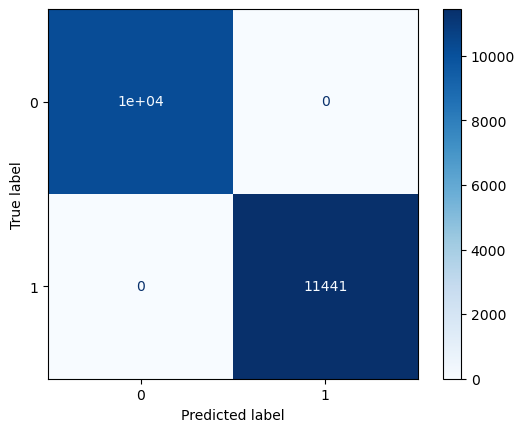

In [4]:
LGBM_baseline = LGBModel('LGBM_baseline', )
LGBM_baseline.train_pipeline(df_train, random_state=RANDOM_STATE)

[LGBM_baseline] Preprocessing 10000 rows...
              precision    recall  f1-score   support

           0     0.9787    0.8345    0.9009      4906
           1     0.8604    0.9825    0.9174      5094

    accuracy                         0.9099     10000
   macro avg     0.9196    0.9085    0.9091     10000
weighted avg     0.9185    0.9099    0.9093     10000



c:\Users\ivan.bernacchia\AppData\Local\anaconda3\envs\hack_03\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


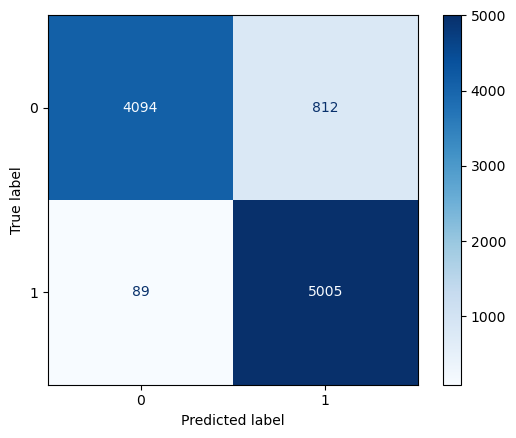

In [5]:
LGBM_baseline.test_pipeline(df_test.sample(10000))

## 3. Hypertuning
Given the high dimensionality of features and the complexity of the `XGBoost` algorithm, performing an exhaustive search of all parameter combinations is computationally prohibitive. To optimize performance, we utilize `RandomizedSearchCV` instead of `GridSearchCV`.

While `GridSearchCV` evaluates every possible combination in a fixed grid, `RandomizedSearchCV` samples a fixed number of parameter settings from specified distributions. This approach allows us to explore a wider range of hyperparameters (like learning rate, tree depth, and regularization) more efficiently, often finding an optimal solution in a fraction of the time.

For the cross-validation strategy, we use a 2-fold approach (cv=2) on a controlled subset. This ensures that the model's generalization is tested across different data partitions while keeping the memory footprint low, which is critical when working with GPU-accelerated training and large embedding arrays on Windows systems.

In [3]:
# Valid hyperparameters for XGBClassifier
lgbm_param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 64, 128],
    'subsample': [0.8, 0.9],       
    'colsample_bytree': [0.8, 0.9],  
    'subsample_freq': [5],         
    'max_depth': [-1, 10, 20]
}

In [7]:
# tuning
LGBM_graph = LGBModel("LGBM_graph", tree_method="hist", force_row_wise=True)
LGBM_graph.hypertune_pipeline(df_train, df_val, lgbm_param_grid,
                            n_jobs=N_JOBS, 
                            n_iter=20,
                            cv=2, 
                            scoring="f1_weighted",
                            random_state=RANDOM_STATE,
                            verbose=0,  # 2 to see warning and info
                        )

[LGBM_graph] Starting Randomized Search...
[LGBM_graph] Preprocessing 2162520 rows...
[LGBM_graph] Preprocessing 391242 rows...
[LightGBM] [Info] Number of positive: 97810, number of negative: 97811
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2812
[LightGBM] [Info] Number of data points in the train set: 195621, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499997 -> initscore=-0.000010
[LightGBM] [Info] Start training from score -0.000010
[LightGBM] [Info] Number of positive: 97811, number of negative: 97810
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info

KeyboardInterrupt: 

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

In [ ]:
LGBM_graph.test_pipeline(df_test)

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [ ]:
#TODO
LGBM_graph.save_model()